In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from AIce.functions import torchRMSE,trainloader,redim,getRMSE,testloader
from  AIce.models import uv256NN
from AIce.plotting import ResidualOnTheMap,PredAgainstTarget
from time import strftime

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    All inputs in degrees, can be arrays
    Returns distance in m
    """
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371000 * c  # m



In [37]:
device='cuda'
allinput=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
#lst=['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'bath']
#weightpath='./weights/UV_5inputs_20E_0.001lr_18-13h_37m_54s.pt'

testdata,_,_,means,stds,maxes,labels=testloader('../data/DRIFT_DATA_TRAIN.csv',inputlist=allinput ,target='u/v',
                                trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv')# Get the means,stds,maxes using the longest list possible

testdata=redim(testdata,
               means=means,
               stds=stds,
               maxes=maxes)

testdata['anglewind']=np.degrees(np.arctan2(testdata['u_ERA5'],testdata['v_ERA5']))

print(len(testdata))

Bath size is the full test set
Target is u/v components of the wind normalized by z-score
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
339156


110285
[-108.1101685] [-6.2690536] [-2.05027408]
76.02332 -112.83366
717.0


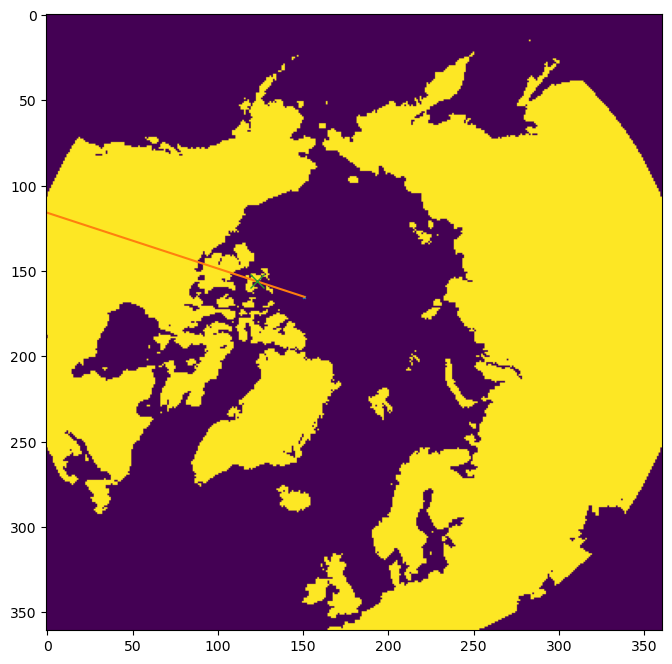

In [34]:
import cartopy.crs as ccrs 

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    All inputs in degrees, can be arrays
    Returns distance in m
    """
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371000 * c  # m


buoy=int(np.random.random()*len(testdata))
print(buoy)
fig, ax = plt.subplots(

    figsize=(8, 8),
    dpi=100,
    #subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

bath=pd.read_csv('../data/bathymetry_EASE.csv', header= None)
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# # (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

#datamask= (1-bath.isna()) # make sure to check where we have data
land=(bath.where(bath==3000,2999)-2999).to_numpy().astype(np.float32) # getting a land numpy array



point=testdata.loc[testdata.index==buoy]

print(((point['anglewind'].values)),
       point['u_ERA5'].values, 
       point['v_ERA5'].values)



a=point['u_ERA5']/point['v_ERA5'] 
b=point['x_EASE']-a*point['y_EASE']


if 45>point['anglewind'].values>=-45:
    until=360
elif 135>point['anglewind'].values>=45:
    until=((360-b)/a)
elif point['anglewind'].values>=135 or point['anglewind'].values<-135:

   until=0
elif -45>=point['anglewind'].values>=-135:
   until=-b/a


y=np.linspace(point['y_EASE'],until,1000)
x=[a*i.item()+b for i in y]

ax.imshow(land)
ax.plot(point['x_EASE'],point['y_EASE'], 'x', markersize=2)
ax.plot(x,y)

inwind=np.array([y,x]).squeeze().T

roundd=np.round(inwind).astype(int)

for i in roundd:
    y_idx=i[0]
    x_idx=i[1]
    if land[y_idx,x_idx]==1:

        ax.plot(x_idx,y_idx, 'x', markersize=10)
        latland=lat_grid[y_idx,x_idx]
        lonland=lon_grid[y_idx,x_idx]
        break


latpoint=lats[buoy]
lonpoint=lons[buoy]
print(latland,lonland)
d2cwind=np.round(haversine_vectorized(latland,lonland,latpoint,lonpoint)*1e-3)
print(d2cwind)


In [38]:
import cartopy.crs as ccrs 

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    All inputs in degrees, can be arrays
    Returns distance in m
    """
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371000 * c  # m

bath=pd.read_csv('../data/bathymetry_EASE.csv', header= None)
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# # (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

#datamask= (1-bath.isna()) # make sure to check where we have data
land=(bath.where(bath==3000,2999)-2999).to_numpy().astype(np.float32) # getting a land numpy array

testdata['d2cwind']= np.zeros_like(testdata['anglewind'], dtype=np.float32)

for buoy in range(testdata.shape[0]):

    point=testdata.loc[testdata.index==buoy]

    a=point['u_ERA5']/point['v_ERA5'] 
    b=point['x_EASE']-a*point['y_EASE']

    if 45>point['anglewind'].values>=-45:
        until=360
    elif 135>point['anglewind'].values>=45:
        until=((360-b)/a)
    elif point['anglewind'].values>=135 or point['anglewind'].values<-135:
        until=0
    elif -45>=point['anglewind'].values>=-135:
        until=-b/a


    y=np.linspace(point['y_EASE'],until,1000)
    x=[a*i.item()+b for i in y]

    inwind=np.array([y,x]).squeeze().T

    roundd=np.round(inwind).astype(int)
    inside = ((roundd >= 0) & (roundd <= 360)).all(axis=1) # selects the inside
    roundd = roundd[inside]

    latland = lonland = np.nan

    for i in roundd:
        y_idx=i[0]
        x_idx=i[1]

        
        if land[y_idx,x_idx]==1:
            latland=lat_grid[y_idx,x_idx]
            lonland=lon_grid[y_idx,x_idx]
            break


    latpoint=lats[buoy]
    lonpoint=lons[buoy]

    testdata.loc[testdata.index[buoy], 'd2cwind']=(np.round(haversine_vectorized(latland,lonland,latpoint,lonpoint)*1e-3))
    percent=(buoy/testdata.shape[0])*100
    if percent %1==0:
        print(percent)

print(testdata)

0.0


KeyboardInterrupt: 

80047


KeyboardInterrupt: 

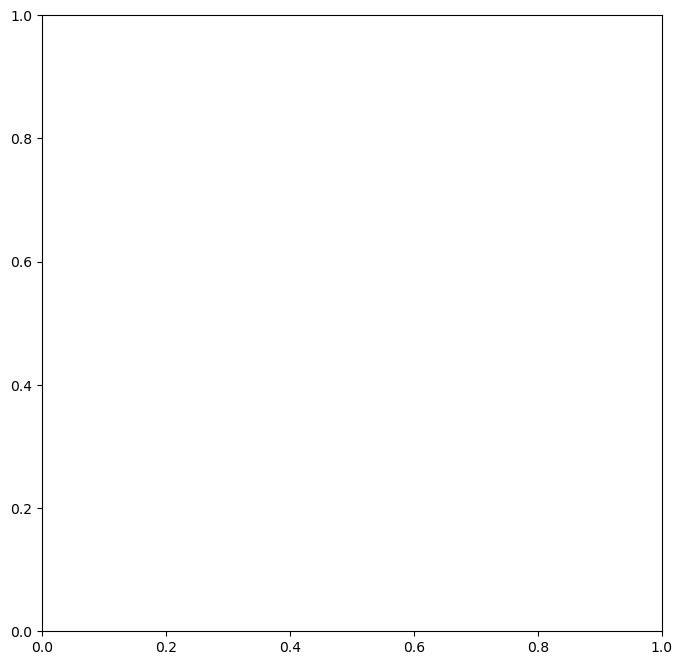

In [5]:
import cartopy.crs as ccrs 

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    All inputs in degrees, can be arrays
    Returns distance in m
    """
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371000 * c  # m


buoy=int(np.random.random()*len(testdata))
print(buoy)
fig, ax = plt.subplots(

    figsize=(8, 8),
    dpi=100,
    #subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

bath=pd.read_csv('../data/bathymetry_EASE.csv', header= None)
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# # (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

#datamask= (1-bath.isna()) # make sure to check where we have data
land=(bath.where(bath==3000,2999)-2999).to_numpy().astype(np.float32) # getting a land numpy array

a=testdata['u_ERA5']/testdata['v_ERA5'] 
b=testdata['x_EASE']-a*testdata['y_EASE']


until=[360 if 45>i>=-45 else ((360-b)/a) if  135>i>=45 else 0 if i>=135 or i<-135 else -b/a for i in testdata['anglewind'].values]

y=np.linspace(point['y_EASE'],until,1000)
x=[a*i.item()+b for i in y]

ax.imshow(land)
ax.plot(point['x_EASE'],point['y_EASE'], 'x', markersize=2)
ax.plot(x,y)

inwind=np.array([y,x]).squeeze().T

roundd=np.round(inwind).astype(int)

for i in roundd:
    y_idx=i[0]
    x_idx=i[1]
    if land[y_idx,x_idx]==1:

        ax.plot(x_idx,y_idx, 'x', markersize=10)
        latland=lat_grid[y_idx,x_idx]
        lonland=lon_grid[y_idx,x_idx]
        break


latpoint=lats[buoy]
lonpoint=lons[buoy]
print(latland,lonland)
d2cwind=np.round(haversine_vectorized(latland,lonland,latpoint,lonpoint)*1e-3)
print(d2cwind)

land[y,x]